In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
base_dir = '../../'
tiff_dir = os.path.join(base_dir, "Img_Denoised")

cell_table_dir = os.path.join(base_dir, "segmentation/cell_table_Denoised")

In [145]:
cost_tb = pd.read_csv('cost_signature.csv',index_col=0)
cost_tb.replace({'+':1,'-':-1},inplace=True)
cost_tb.Immune
#cost_tb = pd.concat((cost_tb,pd.DataFrame.from_dict({'PD-L1':{'Immune':-1,'Non-immune':1}}).T))

CD45            1
CD20            1
CD3             1
CD68            1
CD107a          1
CD14            1
CD163           1
Pan-keratin    -1
E-Cadherin     -1
Beta-Catenin   -1
Vimentin       -1
Alpha-SMA      -1
VEGF           -1
Name: Immune, dtype: int64

In [135]:
#cell_table = pd.read_csv(cell_table_dir+'/cell_table_size_normalized.csv')
adata = sc.read_h5ad('../phenotyping/phenograph/data/sc_protein.h5ad')

In [136]:
!ls ../../segmentation/cell_table_Denoised/

cell_table_arcsinh_transformed.csv  cell_table_size_normalized.csv


In [137]:
adata

AnnData object with n_obs × n_vars = 3013318 × 38
    obs: 'acquisition_ID', 'Leap_ID', 'SLIDE_NUMBER', 'BIOBANK_ID', 'SAMPLE_TYPE_(CORE/RESECTION)', 'FORMAT_(FFPE/FROZEN)', 'FORCE_TRIAL?_(Y/N)', 'DATE_SECTIONED', 'H&E_NOTES', 'ST_NOTES', 'Response', 'COMMENTS', 'note_if_frozen_(otherwise_FFPE)', 'Extreme_non-responder_(death_within_2_years?)'
    uns: 'pca'
    obsm: 'X_pca', 'spatial'
    varm: 'PCs'

In [147]:
markers = list(set(cell_table.columns)&set(cost_tb.index))

In [139]:
prot_table = pd.DataFrame(adata.X,columns = adata.var.index)

<Axes: >

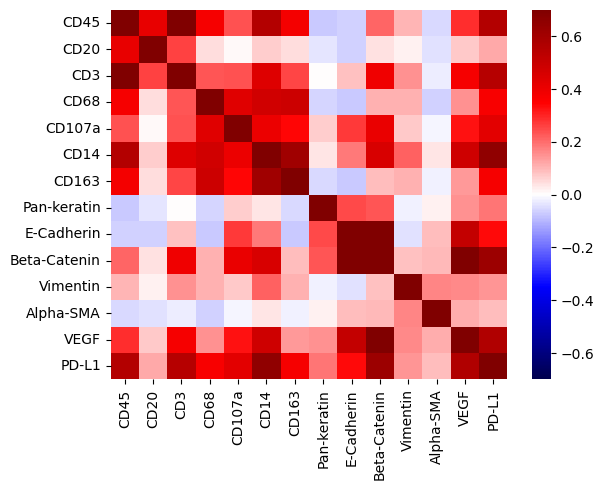

In [140]:
sns.heatmap(prot_table[cost_tb.index].corr(),cmap = 'seismic',vmin = -0.7,vmax = 0.7)

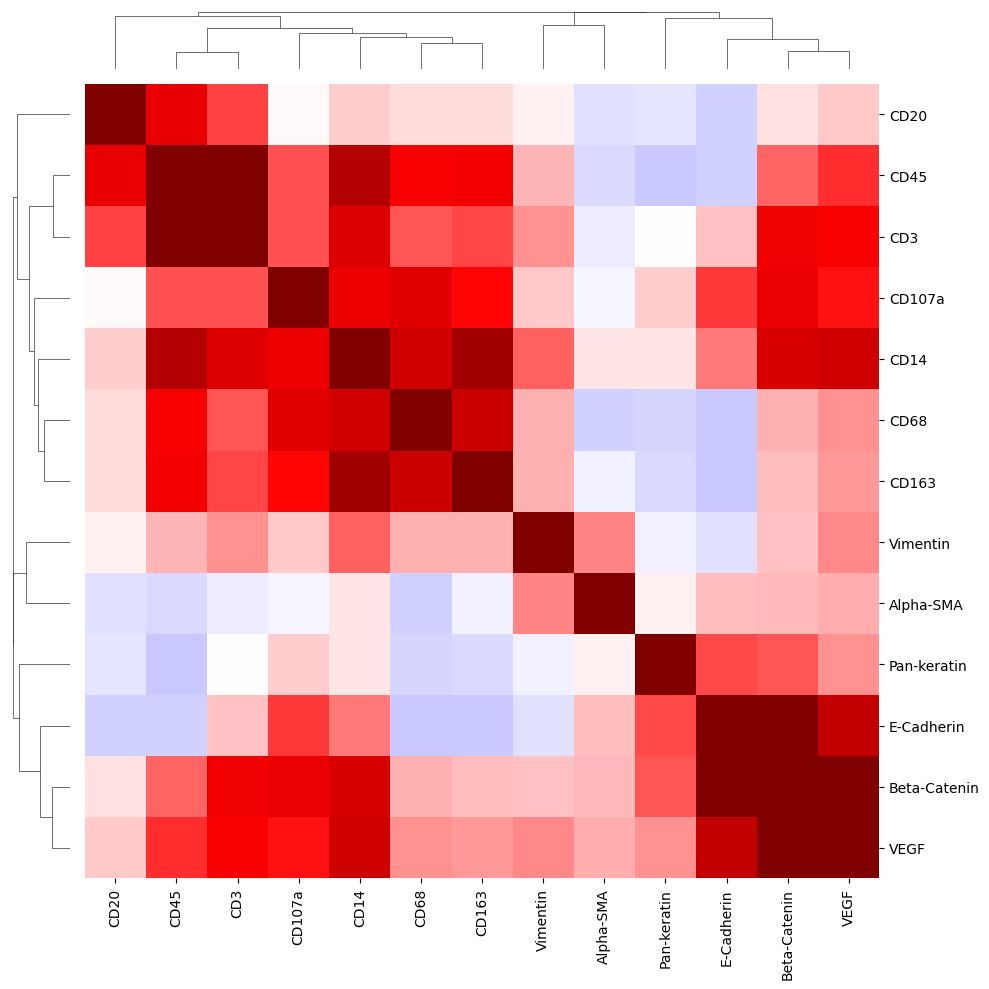

In [78]:

sns.clustermap(prot_table[cost_tb.index].corr(),vmin=-0.7,vmax = 0.7,cmap = 'seismic',dendrogram_ratio=0.07,cbar_pos= None)
plt.tight_layout()
#plt.savefig('figures/cell_corr_selected_p.png')

In [188]:
cost_tb[cost_tb>0].index
prot_table.columns

Index(['Alpha-SMA', 'B7-H4', 'Beta-Catenin', 'CD107a', 'CD11b', 'CD14', 'CD16',
       'CD163', 'CD20', 'CD27', 'CD3', 'CD31', 'CD366', 'CD38', 'CD4', 'CD44',
       'CD45', 'CD45RO', 'CD68', 'CD8a', 'Carboplatin', 'Collage-Type_I',
       'DNA1', 'DNA2', 'E-Cadherin', 'EGFR', 'FOXP3', 'Granzyme-B',
       'HLA-DR-DQ-DP', 'Ki-67', 'PD-1', 'PD-L1', 'PD-L2', 'Pan-keratin',
       'Tbet', 'VEGF', 'Vimentin', 'p53'],
      dtype='object')

compute z score

In [150]:
def z_score_metric(prot,cost_tb):
    '''Score indicating how likely to be immune a cell is'''
    m = (cost_tb.Immune.mean())*(prot.mean())
    #CHECK THE STD HERE
    s = (cost_tb.Immune.abs().sum())*(prot.var())
    z_score = (prot@ cost_tb.Immune/len(cost_tb)-m)/(np.sqrt(s/len(cost_tb)))
    return z_score
x = prot_table.loc[:,markers].values
z_score = z_score_metric(x,cost_tb.loc[markers])


In [103]:
cost_tb.Immune

CD45            1
CD20            1
CD3             1
CD68            1
CD107a          1
CD14            1
CD163           1
Pan-keratin    -1
E-Cadherin     -1
Beta-Catenin   -1
Vimentin       -1
Alpha-SMA      -1
VEGF           -1
Name: Immune, dtype: int64

In [66]:
cost_tb2 = cost_tb.copy()
cost_tb2[cost_tb2<0] = 0
a,b = x@ cost_tb2.loc[markers].Immune,x@ cost_tb2.loc[markers]['Non-immune']


In [71]:
a = cost_tb2.loc[markers].Immune.values
b = cost_tb2.loc[markers]['Non-immune'].values
a,b = x[:,a>0].mean(axis = 1),x[:,b>0].mean(axis = 1)


/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to 

<Axes: ylabel='Count'>

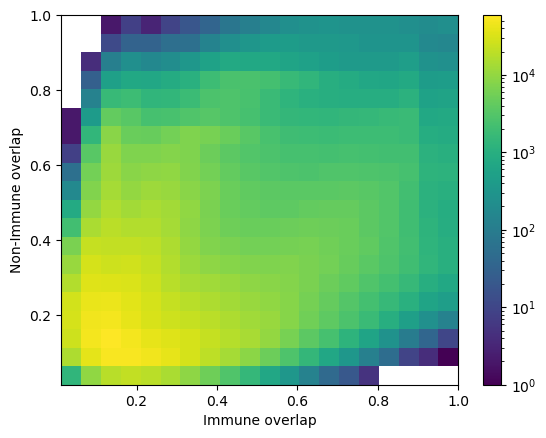

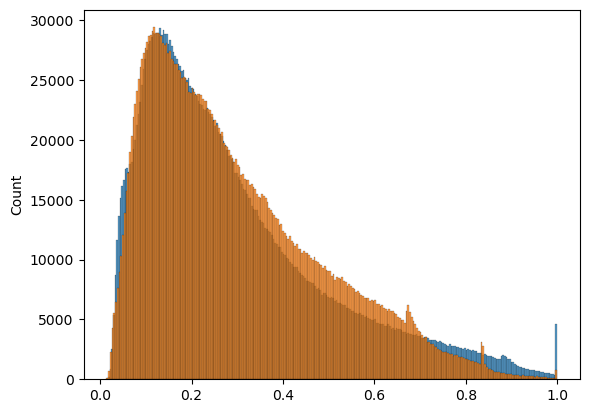

In [46]:
import matplotlib as mpl
#plt.scatter(a,b,s = 0.5)
thr = 6
_ = plt.hist2d(a,b,bins = 20,norm=mpl.colors.LogNorm())
plt.colorbar()
plt.xlabel('Immune overlap')
plt.ylabel('Non-Immune overlap')
plt.figure()
sns.histplot(a)
sns.histplot(b)

In [59]:
np.corrcoef(a,b)


array([[1.        , 0.49539476],
       [0.49539476, 1.        ]])

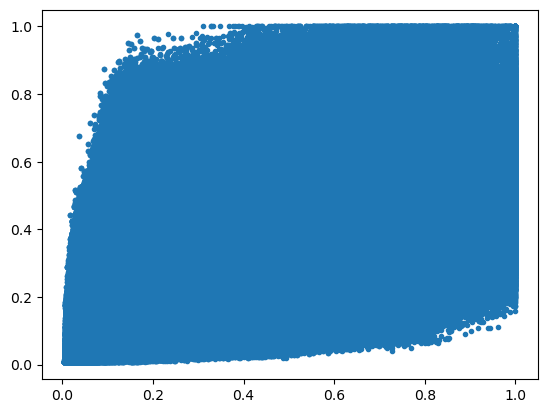

In [127]:
plt.plot(a,b,'.')

In [79]:
from sklearn.cluster import KMeans

# Assuming 'X' contains your data with both features
kmeans = KMeans(n_clusters=2)
clusters = kmeans.fit_predict(prot_table[cost_tb.index])


/home/giuseppe/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [80]:
data= np.stack((a,b)).T
cluster_0 = data[clusters == 0]
cluster_1 = data[clusters == 1]

Text(0, 0.5, 'Non-Immune overlap')

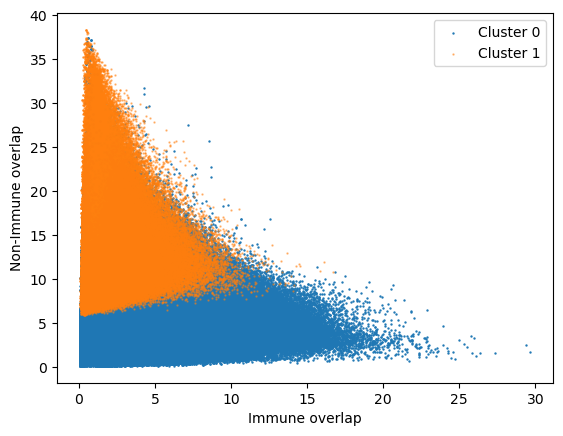

In [153]:
plt.scatter(cluster_0[:, 0], cluster_0[:, 1], label='Cluster 0',s= 0.5)
plt.scatter(cluster_1[:, 0], cluster_1[:, 1], label='Cluster 1',alpha = 0.5,s = 0.5)
plt.legend()
plt.xlabel('Immune overlap')
plt.ylabel('Non-Immune overlap')

In [54]:

corr = prot_table.loc[:,markers].corr()

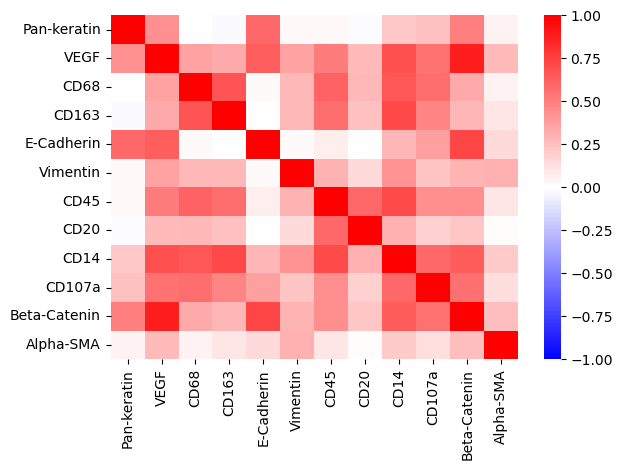

In [55]:
#plt.figure(figsize = (15,10))
sns.heatmap(corr,vmin=-1,vmax = 1,cmap = 'bwr')
plt.tight_layout()
#plt.savefig('figures/cell_corr_selected_p.pdf')

In [52]:
corr_all = norm_table.corr()

<Figure size 1500x1000 with 0 Axes>

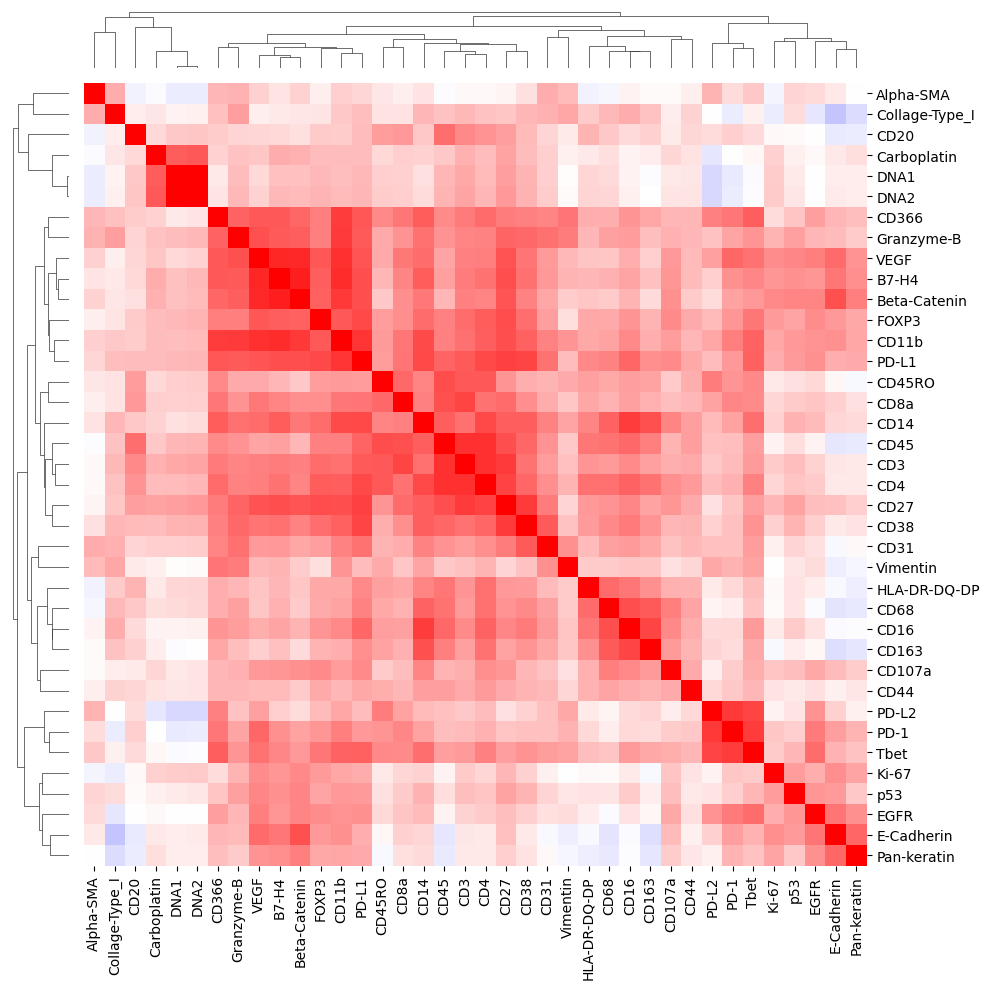

In [53]:
plt.figure(figsize = (15,10))
sns.clustermap(corr_all,vmin=-1,vmax = 1,cmap = 'bwr',dendrogram_ratio=0.07,cbar_pos= None)
plt.tight_layout()
#plt.savefig('figures/cell_corr_all_p.pdf')

(3964212,)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


6.096708897494635

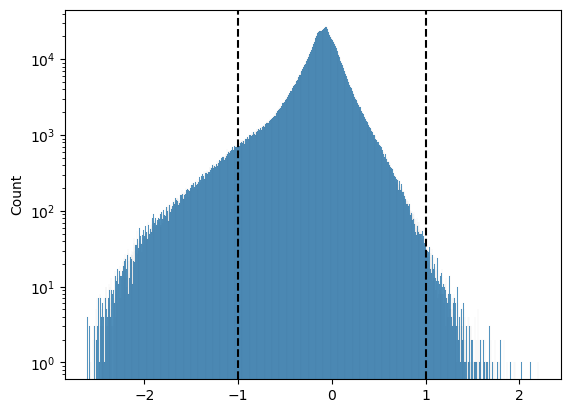

In [152]:
sns.histplot(z_score)
plt.axvline(-1,c = 'k',ls = '--')
plt.axvline(1,c = 'k',ls = '--')
plt.semilogy()
import scipy
scipy.stats.kurtosis(z_score,fisher = True)

In [97]:
np.std(z_score)

0.3188040242925778

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


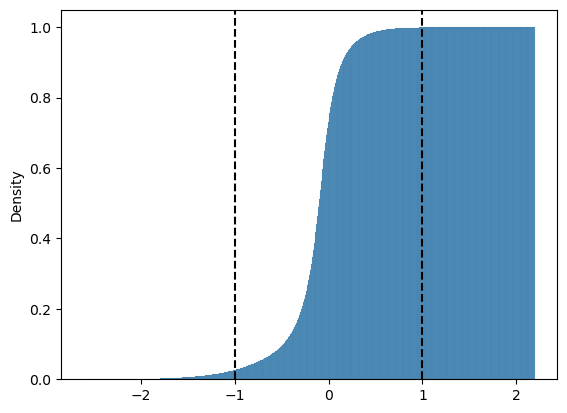

In [151]:
sns.histplot(z_score,cumulative=True,stat = 'density')
plt.axvline(-1,c = 'k',ls = '--')
plt.axvline(1,c = 'k',ls = '--')

(array([229073., 155479., 135204., 122626., 109066.,  91997.,  74519.,
         60755.,  48733.,  39127.,  31058.,  25737.,  21379.,  18544.,
         16349.,  14267.,  12543.,  10787.,   9554.,  73203.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

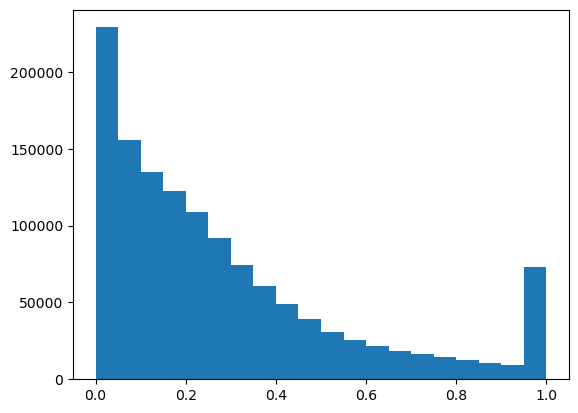

In [125]:
prot_table.loc[:,cost.index].shape, cost.shape
plt.hist(prot_table.loc[:,cost.index].values.ravel(),20)

In [92]:
prot_table.loc[:,cost.index].values>np.percentile(prot_table.loc[:,cost.index].values,95,axis = 0)

array([[ True,  True,  True, ...,  True, False,  True],
       [ True, False, False, ...,  True, False,  True],
       [ True,  True, False, ...,  True, False,  True],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [118]:
prot_table.loc[:,cost.index]
for col in cost.index:
    d = prot_table[col].copy()
    d = d/np.percentile(d,95)
    d[d>1] = 1
    prot_table[col] = d


0        1.000000
1        1.000000
2        1.000000
3        0.302490
4        0.347998
           ...   
99995    0.115249
99996    0.025869
99997    0.093076
99998    0.115714
99999    0.135258
Name: VEGF, Length: 100000, dtype: float64

In [62]:
prot_table.loc[:,cost.index].loc[:,cost.Immune>0].sum(axis = 1)
-prot_table.loc[:,cost.index].loc[:,cost.Immune<0].sum(axis = 1)

0     -81.605676
1    -103.575303
2    -189.399710
3     -18.185756
4     -35.377771
5     -34.380570
6     -70.036828
7     -61.837399
8      -4.440141
9     -42.246380
10    -33.939044
11    -97.455523
12    -89.174737
13   -142.722814
14   -130.368114
15    -52.778233
16    -32.402235
17   -145.598848
18    -28.996172
19    -74.800450
dtype: float64

In [16]:
cost_tb.value_counts()
#prot_table.loc[:,cost.index]

Non-immune  Immune
-1           1        7
 1          -1        6
Name: count, dtype: int64

[]

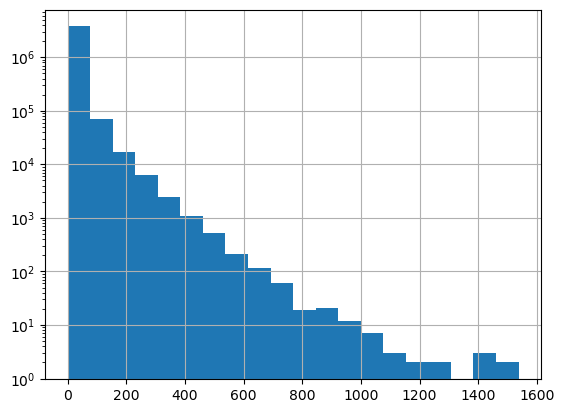

In [50]:
cell_table['Alpha-SMA'].hist(bins = 20)
plt.semilogy()

<Axes: >

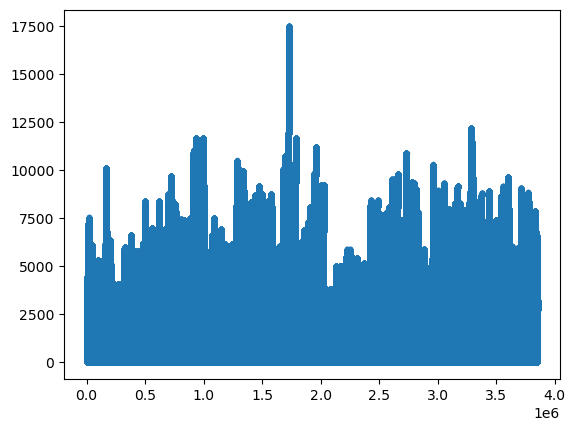

In [58]:
cell_table.label.plot(marker  = '.')

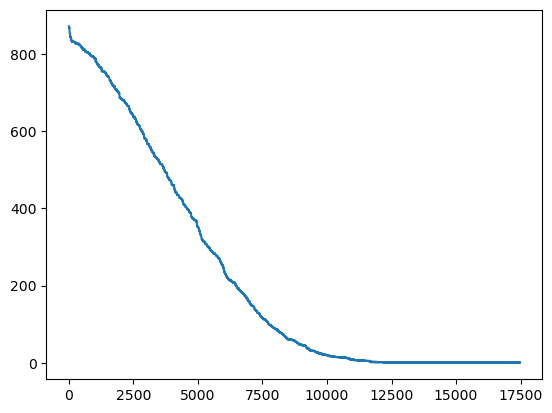

In [76]:
#sns.barplot(cell_table.label.value_counts())
x = cell_table.label.value_counts().index
y = cell_table.label.value_counts().values
plt.plot(x,y)

<Axes: >

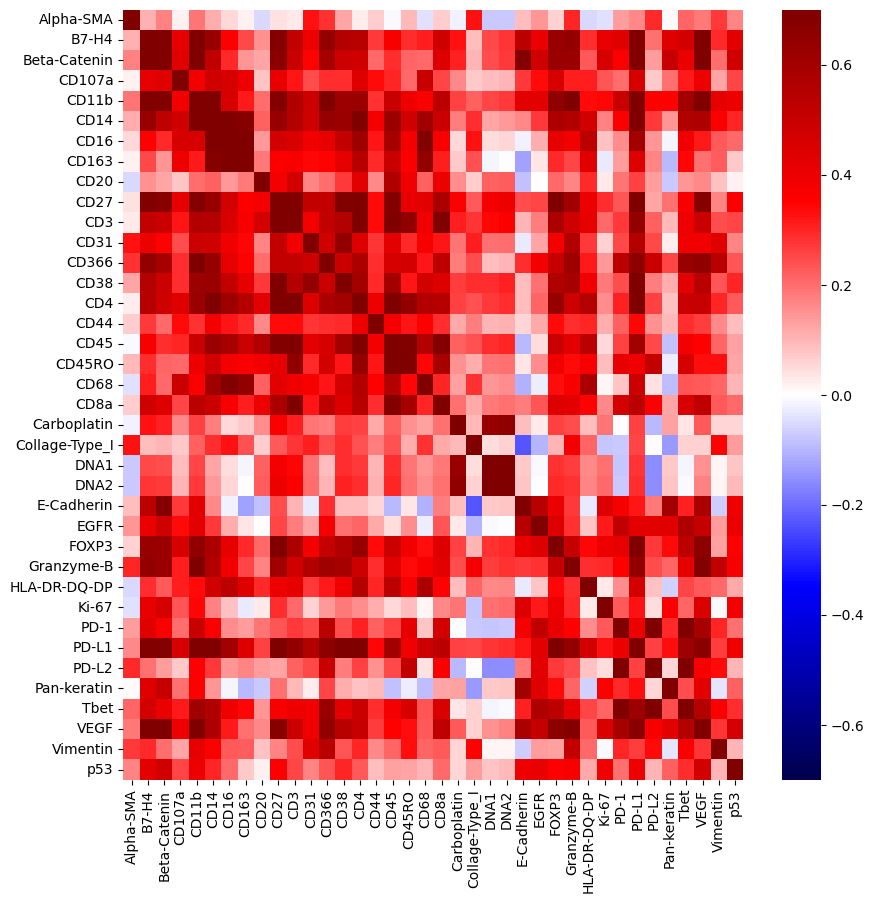

In [39]:
plt.figure(figsize =(10,10))
sns.heatmap(norm_table.corr(),cmap = 'seismic',vmin = -0.7,vmax = 0.7)